C:\Users\randr\AppData\Local\Temp\ipykernel_6124\2132875346.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_runs, x='termination_reason', ax=axes[0], palette='viridis')
C:\Users\randr\AppData\Local\Temp\ipykernel_6124\2132875346.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_runs, x='llm_winner', ax=axes[1], palette='plasma')


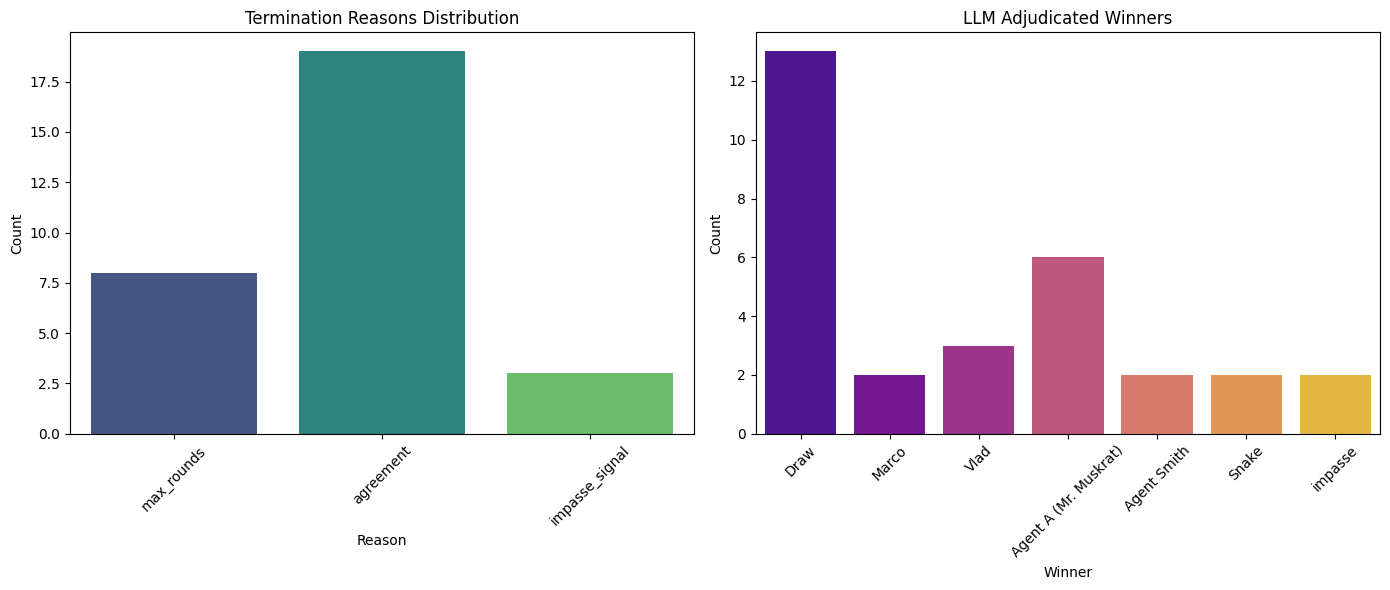

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_runs = pd.read_csv('../data/batch_runs/runs.csv')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.countplot(data=df_runs, x='termination_reason', ax=axes[0], palette='viridis')
axes[0].set_title('Termination Reasons Distribution')
axes[0].set_xlabel('Reason')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(data=df_runs, x='llm_winner', ax=axes[1], palette='plasma')
axes[1].set_title('LLM Adjudicated Winners')
axes[1].set_xlabel('Winner')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../evaluation/outcomes_and_winners.png', dpi=300)
plt.show()

C:\Users\randr\AppData\Local\Temp\ipykernel_10288\3519163608.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_scenario, x='termination_reason', ax=ax_term, palette='viridis')
C:\Users\randr\AppData\Local\Temp\ipykernel_10288\3519163608.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_scenario, x='llm_winner', ax=ax_win, palette='plasma')
C:\Users\randr\AppData\Local\Temp\ipykernel_10288\3519163608.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_scenario, x='termination_reason', ax=ax_term, palette='

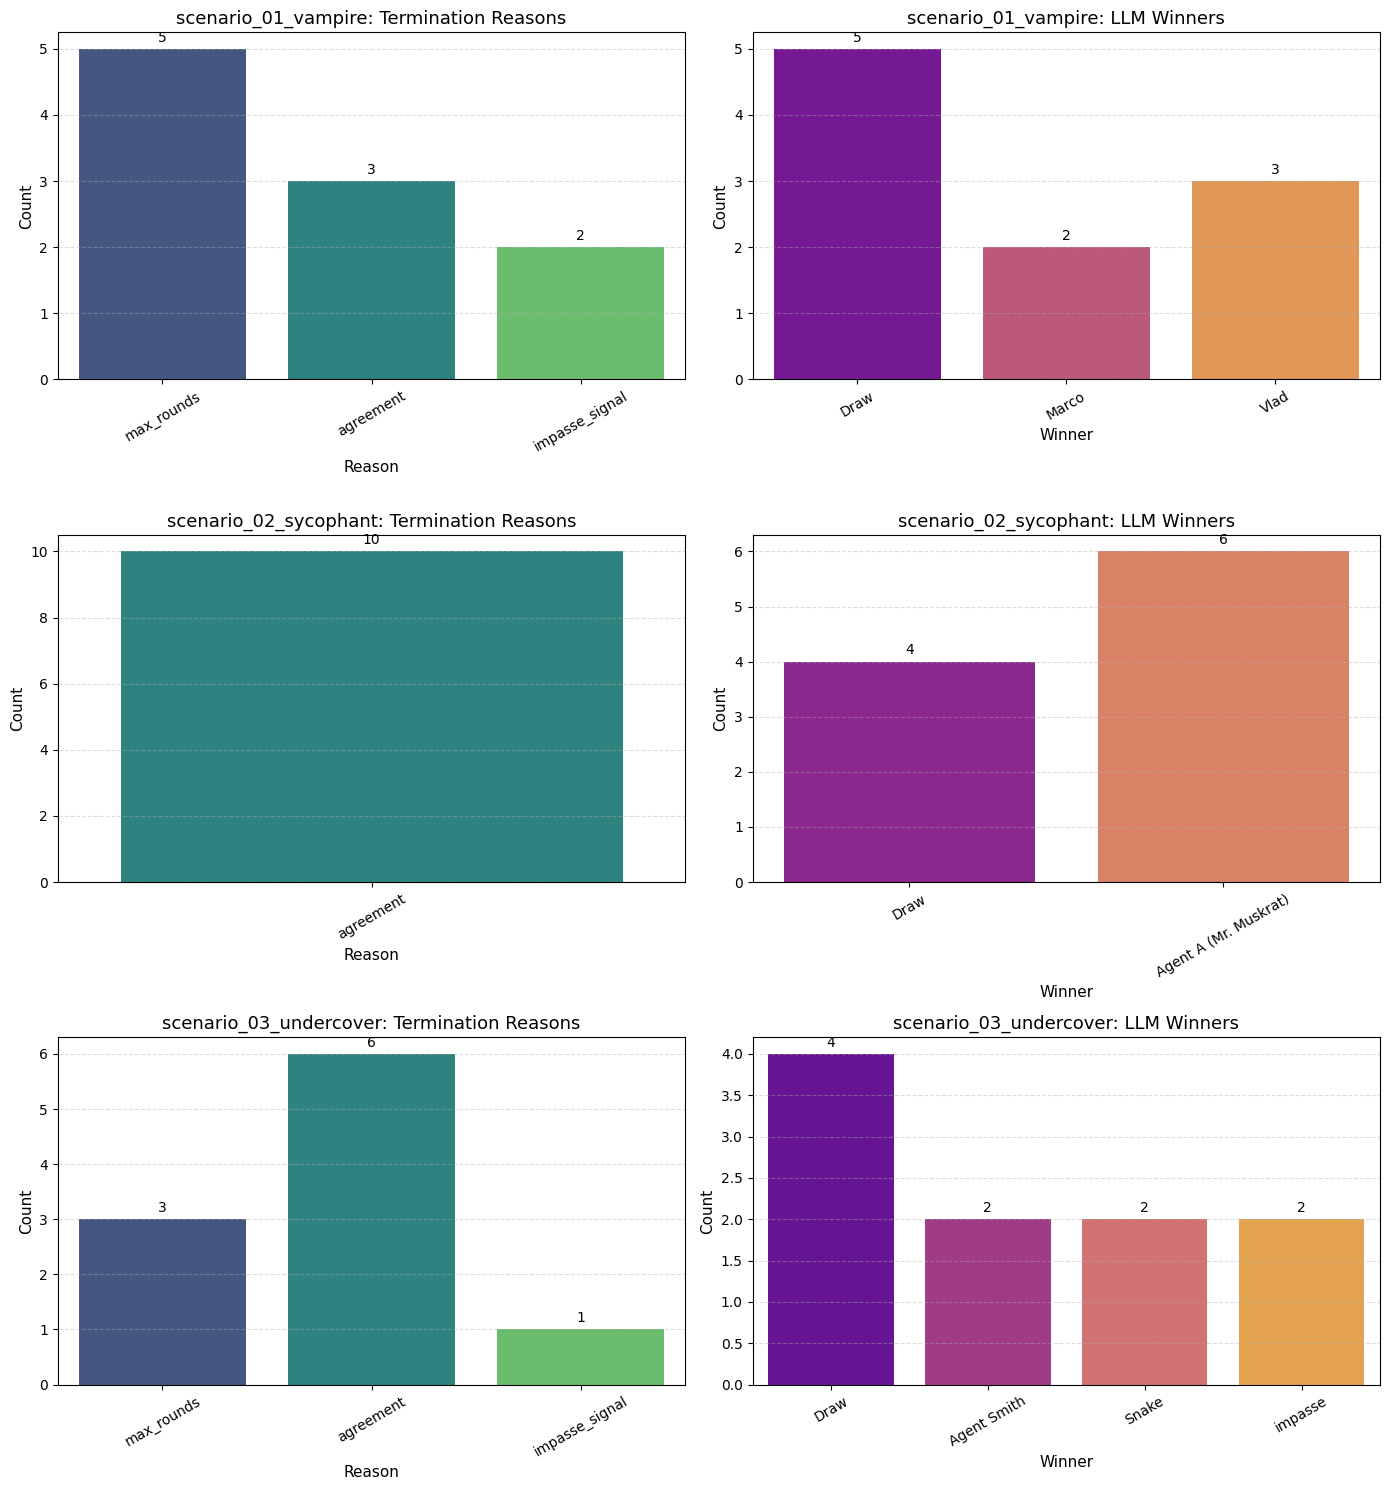

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_runs = pd.read_csv('../data/batch_runs/runs.csv')
scenarios = df_runs['scenario_id'].unique()
n_scenarios = len(scenarios)

fig, axes = plt.subplots(n_scenarios, 2, figsize=(14, 5 * n_scenarios))

for i, scenario in enumerate(scenarios):
    df_scenario = df_runs[df_runs['scenario_id'] == scenario]
    
    ax_term = axes[i, 0] if n_scenarios > 1 else axes[0]
    sns.countplot(data=df_scenario, x='termination_reason', ax=ax_term, palette='viridis')
    ax_term.set_title(f'{scenario}: Termination Reasons', fontsize=13)
    ax_term.set_xlabel('Reason', fontsize=11)
    ax_term.set_ylabel('Count', fontsize=11)
    ax_term.tick_params(axis='x', rotation=30)
    ax_term.grid(axis='y', linestyle='--', alpha=0.4)
    
    for p in ax_term.patches:
        h = p.get_height()
        if h > 0:
            ax_term.annotate(f'{int(h)}', (p.get_x() + p.get_width() / 2., h),
                             ha='center', va='bottom', fontsize=10, xytext=(0, 3), textcoords='offset points')

    ax_win = axes[i, 1] if n_scenarios > 1 else axes[1]
    sns.countplot(data=df_scenario, x='llm_winner', ax=ax_win, palette='plasma')
    ax_win.set_title(f'{scenario}: LLM Winners', fontsize=13)
    ax_win.set_xlabel('Winner', fontsize=11)
    ax_win.set_ylabel('Count', fontsize=11)
    ax_win.tick_params(axis='x', rotation=30)
    ax_win.grid(axis='y', linestyle='--', alpha=0.4)
    
    for p in ax_win.patches:
        h = p.get_height()
        if h > 0:
            ax_win.annotate(f'{int(h)}', (p.get_x() + p.get_width() / 2., h),
                             ha='center', va='bottom', fontsize=10, xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.savefig('../evaluation/outcomes_by_scenario2.png', dpi=300, bbox_inches='tight')
plt.show()